# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [232]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [233]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

Connect to your Google Drive to load your dataset within your drive.

In [234]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load your geospatial dataset.

In [235]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2023.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2023.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [236]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

54

In [237]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

54

Combine the datasets

In [238]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [239]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [240]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [241]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2023 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2023

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((210639.5 176026.668, 210670.31...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((149853.269 223793.793, 149868....",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((149718.149 224040.117, 149718....",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((149689.553 224014.322, 149718....",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((157080.781 233460.18, 156758.2...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((200132.032 162108.059, 200113....",bl,a,gh
5259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((50815.371 196977.204, 50761.33...",qs° + kbf + pins,2310,hab
16985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((97137.412 217338.297, 97076.95...",bl + bu,a,gh
23636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((231730.75 211937.313, 231733.1...",kbac,235,gh


Convert multipolygon to points.

In [242]:
datagrassbwk2023["geometry"] = datagrassbwk2023.geometry.centroid
datagrassbwk2023

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (210486.967 176022.231),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (149901.763 224024.613),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (149718.286 224040.274),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (149705.391 224026.224),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (156920.131 233488.622),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (200446.317 162319.115),bl,a,gh
5259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (50879.256 197088.478),qs° + kbf + pins,2310,hab
16985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (97171.572 217495.851),bl + bu,a,gh
23636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (231786.47 211979.28),kbac,235,gh


<Axes: >

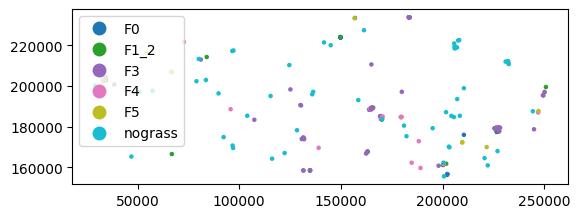

In [243]:
datagrassbwk2023.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [244]:
points_ee = datagrassbwk2023.to_crs("EPSG:4326")
points_ee


,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (5.22846 50.89139),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (4.36735 51.32603),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (4.36472 51.32617),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (4.36453 51.32604),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (4.46822 51.41105),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (5.08389 50.76918),bl,a,gh
5259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (2.95434 51.07544),qs° + kbf + pins,2310,hab
16985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (3.61188 51.26493),bl + bu,a,gh
23636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (5.53921 51.21196),kbac,235,gh


In [245]:
import ee
try:
    ee.Initialize(project="ee-sebastiaanverbesselt")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

print('Earth Engine version:', ee.__version__)
print('geemap version:', geemap.__version__)



Earth Engine version: 1.7.30
geemap version: 0.38.0


In [246]:
def gdf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        features.append(
            ee.Feature(geom, {
                "id": row.name,
                "class": str(row["Level4"]) # Fixed: extracts the actual row value (e.g., 'F0', 'nograss')
            })
        )
    return ee.FeatureCollection(features)

fc = gdf_to_ee(points_ee)


In [247]:
collection_id = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"

In [248]:
# Filter the collection for your year

image_coll = (
    ee.ImageCollection(collection_id)
    .filterDate("2023-01-01", "2024-01-01")
)

# Mosaic the overlapping UTM tiles into a single coherent image
image = image_coll.mosaic()

samples_fc = image.sampleRegions(
    collection=fc,
    scale = 10,
    geometries=True
)

samples_fc

In [249]:
# Use Earth Engine's computeFeatures API to stream pages of vector data
# directly into a native GeoPandas GeoDataFrame
embeddings_gdf = ee.data.computeFeatures({
    'expression': samples_fc,
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})

# Explicitly re-assign the WGS 84 Coordinate Reference System
embeddings_gdf.crs = 'EPSG:4326'

In [250]:
embeddings_gdf

,geometry,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A56,A57,A58,A59,A60,A61,A62,A63,class,id
0,POINT (5.22842 50.8914),-0.221453,-0.179377,-0.172795,-0.008858,0.098424,-0.103406,0.119093,0.066990,0.103406,...,-0.059116,-0.059116,-0.098424,0.017778,0.013841,-0.079723,-0.051734,-0.071111,F0,0
1,POINT (4.36738 51.32601),-0.236463,-0.251965,-0.093564,0.002215,0.066990,-0.135886,0.113741,0.051734,0.098424,...,-0.093564,-0.013841,-0.098424,0.032541,0.032541,-0.055363,-0.062991,-0.093564,F0,1
2,POINT (4.36469 51.32619),-0.192910,-0.292872,0.055363,-0.035433,0.075356,-0.113741,0.113741,-0.010396,-0.088827,...,-0.019931,-0.051734,0.084214,-0.029773,0.071111,-0.084214,0.024606,-0.199862,F0,2
3,POINT (4.36451 51.32601),-0.186082,-0.259900,0.044844,-0.062991,0.032541,-0.113741,0.130165,-0.027128,-0.079723,...,-0.032541,-0.051734,0.103406,-0.013841,0.024606,-0.119093,0.044844,-0.199862,F0,3
4,POINT (4.46818 51.41108),-0.199862,-0.172795,-0.088827,-0.000246,0.071111,-0.119093,0.075356,0.079723,0.088827,...,-0.103406,0.024606,-0.041584,0.071111,0.029773,-0.048228,-0.038447,-0.062991,F0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,POINT (5.08388 50.76914),-0.166336,-0.098424,-0.088827,-0.160000,0.079723,-0.062991,0.214133,-0.098424,0.147697,...,-0.103406,-0.130165,-0.048228,-0.098424,-0.041584,-0.108512,-0.027128,-0.113741,nograss,10440
229,POINT (2.95433 51.07547),-0.172795,-0.044844,-0.199862,0.084214,-0.051734,-0.244152,0.124567,0.244152,0.206936,...,0.084214,0.003014,-0.048228,-0.008858,0.055363,-0.153787,0.001538,-0.059116,nograss,5259
230,POINT (3.6119 51.26492),-0.206936,-0.172795,-0.166336,-0.048228,0.066990,-0.027128,0.153787,0.003014,0.124567,...,0.015748,-0.130165,-0.153787,-0.003014,-0.048228,-0.103406,-0.029773,0.035433,nograss,16985
231,POINT (5.53924 51.21192),-0.160000,-0.186082,-0.135886,0.012057,0.055363,-0.141730,0.153787,0.135886,0.044844,...,0.002215,0.013841,0.017778,0.075356,0.075356,-0.098424,-0.071111,-0.172795,nograss,23636


In [251]:
embeddings_gdf.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2023.csv") # Now saved in WGS 84